# Simulated Annealing — Probability Distribution Over Solution Space

With SA, the probability of being in state $x$ at temperature $T$ follows the **Boltzmann distribution**:
$$P(x) = \frac{e^{-\text{cost}(x)\,/\,T}}{Z}, \quad Z = \sum_{x'} e^{-\text{cost}(x')\,/\,T}$$

At **high $T$**: all solutions nearly equally likely (flat distribution).  
At **low $T$**: probability concentrates entirely on the optimal solution(s).  

We use **7 cities** so we can enumerate *all* $6! = 720$ possible tours exactly and watch probability mass shift in real time.

In [1]:
import math, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import permutations
from sklearn.manifold import MDS

SEED = 7
random.seed(SEED); np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linewidth': 0.5,         'font.family': 'monospace',
})

# ── Cities ──────────────────────────────────────────────────────────────────
N = 7
cities = np.random.rand(N, 2) * 100

# ── Enumerate every possible tour (fix city 0 as start to avoid rotations) ──
all_routes = [(0,) + p for p in permutations(range(1, N))]
n_routes   = len(all_routes)   # 720

def tour_cost(route):
    n = len(route)
    return sum(np.linalg.norm(cities[route[i]] - cities[route[(i+1)%n]])
               for i in range(n))

costs = np.array([tour_cost(r) for r in all_routes])

best_idx  = np.argmin(costs)
worst_idx = np.argmax(costs)
print(f'Tours enumerated : {n_routes}')
print(f'Best  cost       : {costs[best_idx]:.2f}  (tour #{best_idx})')
print(f'Worst cost       : {costs[worst_idx]:.2f}  (tour #{worst_idx})')
print(f'Cost range       : {costs.max()-costs.min():.2f}')

Tours enumerated : 720
Best  cost       : 259.51  (tour #73)
Worst cost       : 509.08  (tour #184)
Cost range       : 249.57


## 1 · The Solution Space
Every bar is one of the 720 tours, sorted by cost (cheapest → most expensive).

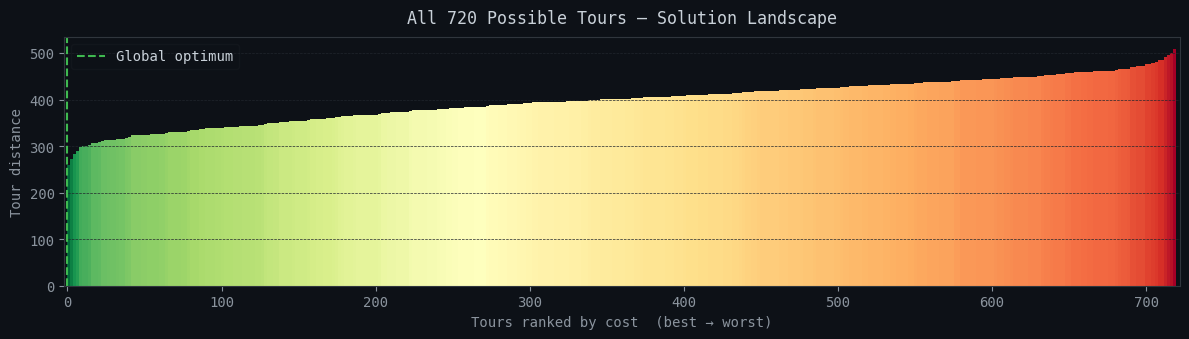

In [2]:
sort_idx   = np.argsort(costs)
costs_sorted = costs[sort_idx]

# Normalize costs to [0,1] for colour mapping
c_norm = (costs_sorted - costs_sorted.min()) / (costs_sorted.max() - costs_sorted.min())
bar_colors = plt.cm.RdYlGn_r(c_norm)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(n_routes), costs_sorted, color=bar_colors, width=1.0, linewidth=0)
ax.axvline(0, color='#3fb950', linewidth=1.5, linestyle='--', label='Global optimum')
ax.set_xlabel('Tours ranked by cost  (best → worst)')
ax.set_ylabel('Tour distance')
ax.set_title('All 720 Possible Tours — Solution Landscape', fontsize=12, pad=10)
ax.legend(framealpha=0.15, edgecolor='#30363d')
ax.grid(True, axis='y', linestyle='--')
ax.set_xlim(-2, n_routes + 2)
plt.tight_layout()
plt.show()

## 2 · Boltzmann Probability at a Single Temperature
Formula: $P(x) \propto e^{-\text{cost}(x)/T}$

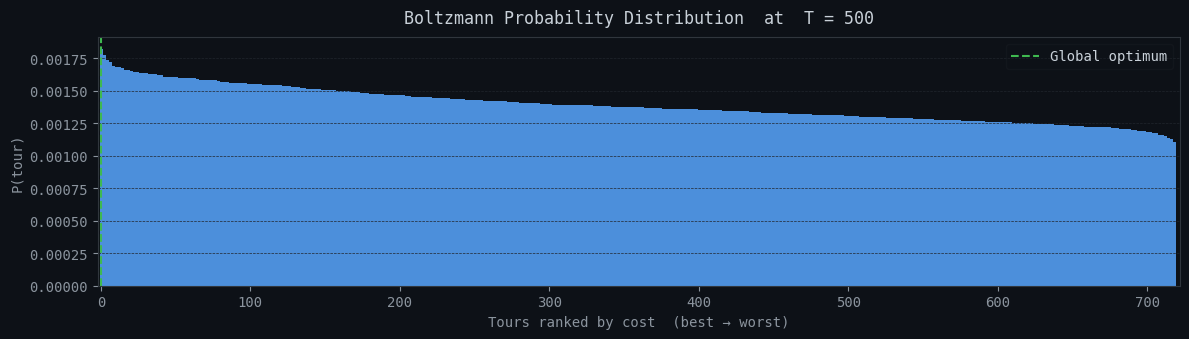

In [3]:
def boltzmann_probs(costs, T):
    """Compute normalised Boltzmann probabilities for given temperature T."""
    log_weights = -costs / T
    log_weights -= log_weights.max()   # numerical stability
    weights = np.exp(log_weights)
    return weights / weights.sum()

# Show the formula and a single example
T_example = 500
probs = boltzmann_probs(costs_sorted, T_example)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.bar(range(n_routes), probs, color='#58a6ff', width=1.0, linewidth=0, alpha=0.85)
ax.axvline(0, color='#3fb950', linewidth=1.5, linestyle='--', label='Global optimum')
ax.set_xlabel('Tours ranked by cost  (best → worst)')
ax.set_ylabel('P(tour)')
ax.set_title(f'Boltzmann Probability Distribution  at  T = {T_example}', fontsize=12, pad=10)
ax.legend(framealpha=0.15, edgecolor='#30363d')
ax.grid(True, axis='y', linestyle='--')
ax.set_xlim(-2, n_routes + 2)
plt.tight_layout()
plt.show()

## 3 · Probability Distribution Snapshots as Temperature Decreases
Each panel is a snapshot at a different temperature. Watch the mass collapse onto the left (optimal) end.

/tmp/ipykernel_8543/2142336706.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


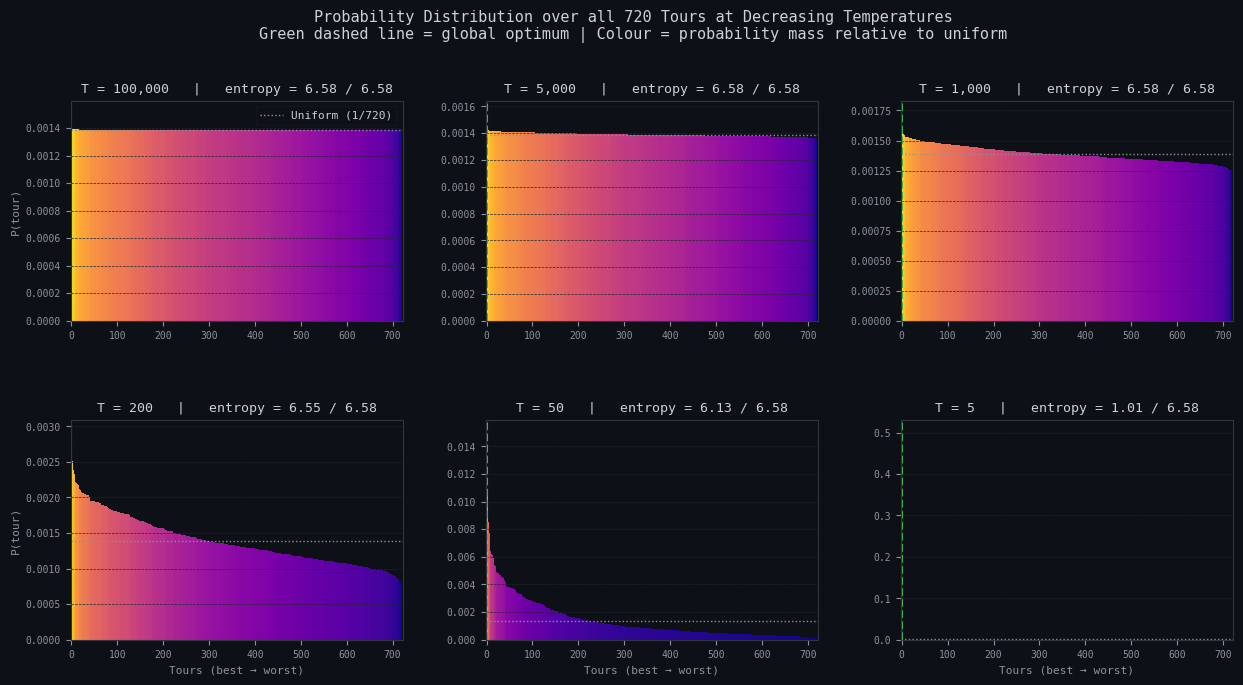

In [4]:
snap_temps = [100_000, 5_000, 1_000, 200, 50, 5]
titles     = [f'T = {t:,}' for t in snap_temps]

fig, axes = plt.subplots(2, 3, figsize=(15, 7),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.25})

uniform_prob = 1.0 / n_routes

for ax, T, title in zip(axes.flat, snap_temps, titles):
    probs = boltzmann_probs(costs_sorted, T)

    # Colour by how much above/below uniform each bar is
    ratio  = probs / uniform_prob
    r_norm = np.clip((ratio - ratio.min()) / (ratio.max() - ratio.min() + 1e-12), 0, 1)
    colors = plt.cm.plasma(r_norm)

    ax.bar(range(n_routes), probs, color=colors, width=1.0, linewidth=0)
    ax.axhline(uniform_prob, color='#8b949e', linewidth=1.0,
               linestyle=':', label='Uniform (1/720)')
    ax.axvline(0, color='#3fb950', linewidth=1.5, linestyle='--')

    # Annotate with entropy
    entropy = -np.sum(probs * np.log(probs + 1e-300))
    max_ent = math.log(n_routes)
    ax.set_title(f'{title}   |   entropy = {entropy:.2f} / {max_ent:.2f}',
                 fontsize=9.5, color='#c9d1d9', pad=6)
    ax.set_xlim(-2, n_routes + 2)
    ax.set_ylim(0, max(probs) * 1.15)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7)
    if ax in axes[:, 0]:
        ax.set_ylabel('P(tour)', fontsize=8)
    if ax in axes[1, :]:
        ax.set_xlabel('Tours (best → worst)', fontsize=8)

# Shared legend
axes[0, 0].legend(framealpha=0.15, edgecolor='#30363d', fontsize=8)

fig.suptitle('Probability Distribution over all 720 Tours at Decreasing Temperatures\n'
             'Green dashed line = global optimum | Colour = probability mass relative to uniform',
             fontsize=11, color='#c9d1d9', y=1.01)
plt.tight_layout()
plt.show()

## 4 · Entropy & Probability Mass on Top-K Tours Over Time
As temperature falls, **entropy** (uncertainty) drops and **top-K probability mass** rises — the algorithm "commits" to a small set of good solutions.

/tmp/ipykernel_8543/3257398203.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


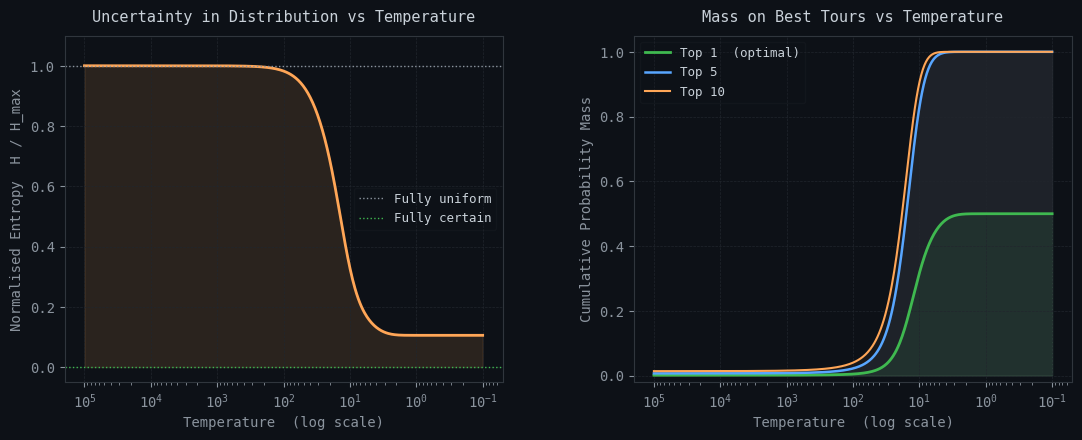

In [5]:
temps_range  = np.logspace(5, -1, 500)   # from 100,000 → 0.1
max_entropy  = math.log(n_routes)

entropies  = []
top1_mass  = []
top5_mass  = []
top10_mass = []

for T in temps_range:
    p = boltzmann_probs(costs_sorted, T)
    entropies.append(-np.sum(p * np.log(p + 1e-300)) / max_entropy)
    top1_mass.append(p[:1].sum())
    top5_mass.append(p[:5].sum())
    top10_mass.append(p[:10].sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5),
                                 gridspec_kw={'wspace': 0.3})

# Entropy
ax1.semilogx(temps_range, entropies, color='#ffa657', linewidth=2)
ax1.fill_between(temps_range, entropies, alpha=0.12, color='#ffa657')
ax1.set_xlabel('Temperature  (log scale)')
ax1.set_ylabel('Normalised Entropy  H / H_max')
ax1.set_title('Uncertainty in Distribution vs Temperature', fontsize=11, pad=10)
ax1.invert_xaxis()
ax1.axhline(1.0, color='#8b949e', linestyle=':', linewidth=1, label='Fully uniform')
ax1.axhline(0.0, color='#3fb950', linestyle=':', linewidth=1, label='Fully certain')
ax1.legend(framealpha=0.15, edgecolor='#30363d', fontsize=9)
ax1.grid(True, linestyle='--')
ax1.set_ylim(-0.05, 1.1)

# Probability mass on top-k
ax2.semilogx(temps_range, top1_mass,  color='#3fb950', linewidth=2,   label='Top 1  (optimal)')
ax2.semilogx(temps_range, top5_mass,  color='#58a6ff', linewidth=1.8, label='Top 5')
ax2.semilogx(temps_range, top10_mass, color='#ffa657', linewidth=1.5, label='Top 10')
ax2.fill_between(temps_range, top1_mass,  alpha=0.10, color='#3fb950')
ax2.fill_between(temps_range, top5_mass,  alpha=0.07, color='#58a6ff')
ax2.fill_between(temps_range, top10_mass, alpha=0.05, color='#ffa657')
ax2.set_xlabel('Temperature  (log scale)')
ax2.set_ylabel('Cumulative Probability Mass')
ax2.set_title('Mass on Best Tours vs Temperature', fontsize=11, pad=10)
ax2.invert_xaxis()
ax2.legend(framealpha=0.15, edgecolor='#30363d', fontsize=9)
ax2.grid(True, linestyle='--')
ax2.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

## 5 · Solution Space Map — 2D Embedding
Each dot is one of the 720 tours, projected into 2D by **MDS** on route-swap distances.  
Colour = tour cost. Size = Boltzmann probability at snapshot temperature.  
The optimal tour glows brightest; nearby tours (structurally similar) also attract mass.

In [6]:
# ── Pairwise route distance: number of edges NOT shared ─────────────────────
def edge_set(route):
    n = len(route)
    return frozenset(
        (min(route[i], route[(i+1)%n]), max(route[i], route[(i+1)%n]))
        for i in range(n)
    )

print('Computing pairwise edge distances… (may take ~30 s)')
edge_sets = [edge_set(r) for r in all_routes]
n         = len(all_routes)
D         = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        shared    = len(edge_sets[i] & edge_sets[j])
        d         = N - shared            # N edges total; fewer shared = farther
        D[i,j] = D[j,i] = d

mds    = MDS(n_components=2, metric=True, dissimilarity='precomputed', random_state=SEED, n_init=1, max_iter=200, normalized_stress=False)
coords = mds.fit_transform(D)
print('MDS embedding done ✓')

Computing pairwise edge distances… (may take ~30 s)
MDS embedding done ✓


/tmp/ipykernel_8543/3902348281.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


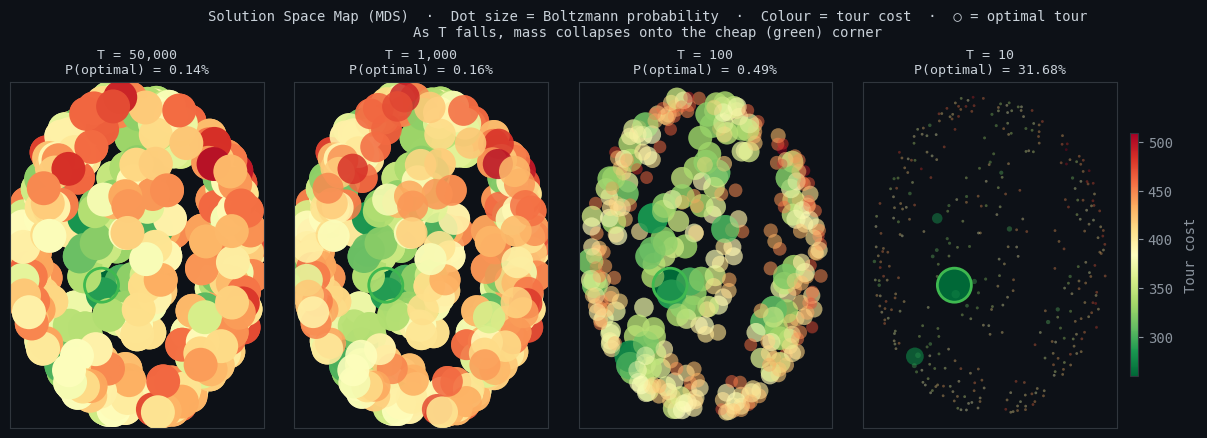

In [7]:
snap_temps_map = [50_000, 1_000, 100, 10]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5),
                          gridspec_kw={'wspace': 0.12})

# Normalize costs for colour mapping
c_norm_all = (costs - costs.min()) / (costs.max() - costs.min())

for ax, T in zip(axes, snap_temps_map):
    probs = boltzmann_probs(costs, T)

    # Bubble size proportional to probability
    # Scale so the largest bubble is visible but not overwhelming
    min_s, max_s = 4, 600
    sizes = min_s + (probs / probs.max()) * (max_s - min_s)

    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    s=sizes,
                    c=c_norm_all,
                    cmap='RdYlGn_r',
                    alpha=np.clip(0.2 + 0.8 * (probs / probs.max()), 0, 1),
                    linewidths=0,
                    zorder=2)

    # Highlight global optimum
    ax.scatter(coords[best_idx, 0], coords[best_idx, 1],
               s=max(sizes[best_idx], 60), color='none',
               edgecolors='#3fb950', linewidths=2, zorder=3)

    # Annotate the optimal tour's probability
    p_opt = probs[best_idx] * 100
    ax.set_title(f'T = {T:,}\nP(optimal) = {p_opt:.2f}%', fontsize=9.5,
                 color='#c9d1d9', pad=6)
    ax.set_xticks([]); ax.set_yticks([])

# Colourbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r',
                             norm=plt.Normalize(costs.min(), costs.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.01, aspect=30)
cbar.set_label('Tour cost', labelpad=8)
cbar.ax.yaxis.set_tick_params(color='#8b949e')

fig.suptitle('Solution Space Map (MDS)  ·  Dot size = Boltzmann probability  ·  '
             'Colour = tour cost  ·  ○ = optimal tour\n'
             'As T falls, mass collapses onto the cheap (green) corner',
             fontsize=10, color='#c9d1d9', y=1.04)
plt.tight_layout()
plt.show()

## 6 · Detailed Probability Flow — Top 20 Tours
Track exactly how much probability each of the 20 best tours accumulates as temperature drops.

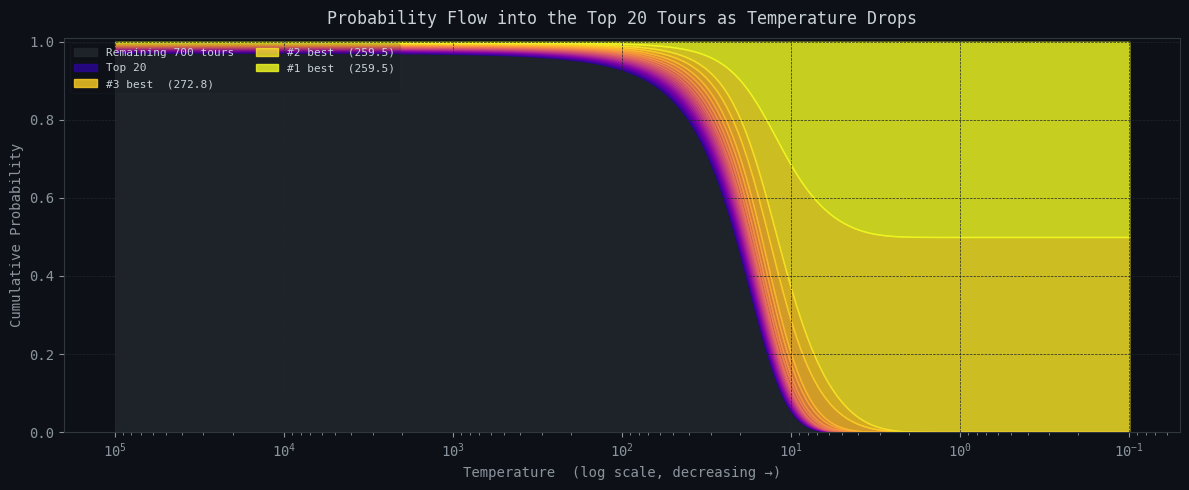

In [8]:
TOP_K = 20
top_k_idx = sort_idx[:TOP_K]   # indices of TOP_K cheapest tours

temps_fine = np.logspace(5, -1, 300)

# For each temperature, compute prob of each of the TOP_K tours
top_k_probs = np.zeros((len(temps_fine), TOP_K))
rest_mass   = np.zeros(len(temps_fine))

for t_idx, T in enumerate(temps_fine):
    p = boltzmann_probs(costs, T)
    top_k_probs[t_idx] = p[top_k_idx]
    rest_mass[t_idx]   = 1 - p[top_k_idx].sum()

# ── Stacked area chart ───────────────────────────────────────────────────────
cmap_top = plt.cm.plasma
fig, ax  = plt.subplots(figsize=(12, 5))

# Stack rest_mass at the bottom first
ax.fill_between(temps_fine, 0, rest_mass, color='#21262d',
                label='Remaining 700 tours', alpha=0.9)

cumulative = rest_mass.copy()
for k in range(TOP_K - 1, -1, -1):      # plot worst of top-20 first so best is on top
    col   = cmap_top(1 - k / TOP_K)
    label = f'#{k+1} best  ({costs_sorted[k]:.1f})' if k < 3 else (f'Top {k+1}' if k == TOP_K-1 else None)
    ax.fill_between(temps_fine, cumulative, cumulative + top_k_probs[:, k],
                    color=col, alpha=0.82, label=label)
    cumulative += top_k_probs[:, k]

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('Temperature  (log scale, decreasing →)')
ax.set_ylabel('Cumulative Probability')
ax.set_ylim(0, 1.01)
ax.set_title('Probability Flow into the Top 20 Tours as Temperature Drops',
             fontsize=12, pad=10)
ax.legend(loc='upper left', framealpha=0.15, edgecolor='#30363d',
          fontsize=8, ncol=2)
ax.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

## 7 · Summary — Optimal Tour
The tour that, at zero temperature, absorbs 100% of the probability mass.

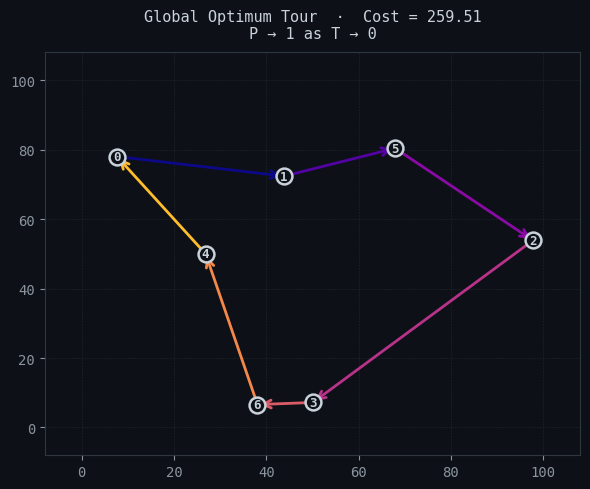

Optimal route: 0 → 1 → 5 → 2 → 3 → 6 → 4 → 0
Cost          : 259.5137
P(optimal) at T=0.001: 50.000000%


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

best = all_routes[best_idx]
xs   = [cities[c, 0] for c in best] + [cities[best[0], 0]]
ys   = [cities[c, 1] for c in best] + [cities[best[0], 1]]

# Colour edges by position in tour
cmap_e = plt.cm.plasma
for i in range(N):
    col = cmap_e(i / N)
    ax.annotate('', xy=(xs[i+1], ys[i+1]), xytext=(xs[i], ys[i]),
                arrowprops=dict(arrowstyle='->', color=col, lw=2, mutation_scale=14))

ax.scatter(cities[:, 0], cities[:, 1], s=130, color='#0d1117',
           edgecolors='#c9d1d9', linewidths=1.8, zorder=4)
for i, (x, y) in enumerate(cities):
    ax.text(x, y, str(i), ha='center', va='center',
            fontsize=9, color='#c9d1d9', zorder=5, fontweight='bold')

ax.set_title(f'Global Optimum Tour  ·  Cost = {costs[best_idx]:.2f}\n'
              f'P → 1 as T → 0',
              fontsize=11, pad=10)
ax.set_xlim(-8, 108); ax.set_ylim(-8, 108)
ax.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()

print('Optimal route:', ' → '.join(map(str, best + (best[0],))))
print(f'Cost          : {costs[best_idx]:.4f}')
print(f'P(optimal) at T=0.001: {boltzmann_probs(costs, 0.001)[best_idx]*100:.6f}%')